# Table of Contents

1. [Load Data](#load-data)
2. [Data Cleaning and Feature engineering](#data-cleaning-and-feature-engineering)
3. [Dimentionality Reduction](#dimentionality-reduction)
4. [Imported Cluster Labels](#imported-cluster-Labels)
5. [Result Analysis & Visualizations](#result-analysis--visualizations)


## Load Data

In [17]:
import pandas as pd

csv_path = "../Clustering/clustering_Cleaned.csv"
df = pd.read_csv(csv_path)

if "transaction_count_Western Union" in df.columns:
    df = df.rename(columns={"transaction_count_Western Union": "transaction_count_Western_Union"})

df.head()

C:\Users\houju\AppData\Local\Temp\ipykernel_45504\358577052.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,customer_id,kyc_type,province,city,industry_code,occupation_code,sales_cents,account_age,birth_business_age,total_transaction_count,...,abm_transaction_count,abm_cash_count,abm_non_cash_count,abm_cash_to_non_cash_ratio,Debit_Amount_Total,Credit_Amount_Total,Averagetime_between_alltransaction,std_time_between_transactions,median_time_between_transactions,pct_transactions_top10_busiest_days
0,SYNID0100000167,individual,ON,TORONTO,NaN,10019,NaN,14.28,53.92,18,...,NaN,NaN,NaN,NaN,169868.00,986385.00,5.255900,5.064565,3.519861,11.111111
1,SYNID0100000431,individual,other,other,NaN,72310,NaN,7.58,37.79,108,...,14.0,12.0,2.0,6.0,1149349.38,649001.25,0.828102,0.839584,0.619653,19.444444
2,SYNID0100000485,individual,ON,BRAMPTON,NaN,RETIRED,NaN,28.47,90.67,40,...,2.0,1.0,1.0,1.0,368832.00,652412.74,2.328543,2.692905,1.462859,20.000000
3,SYNID0100000539,individual,other,other,NaN,RETIRED,NaN,40.64,81.16,150,...,NaN,NaN,NaN,NaN,1024417.00,16498.00,0.607231,0.669683,0.343773,20.000000
4,SYNID0100000932,individual,ON,TORONTO,NaN,RETIRED,NaN,13.48,62.30,219,...,2.0,2.0,0.0,NaN,2757414.97,14581127.00,0.419258,0.468692,0.239010,24.200913


In [18]:
# Drop specified columns
cols_to_drop = ['card_transaction_count', 'abm_transaction_count', 'Debit_Amount_Total', 'Credit_Amount_Total', 'card_ecommerce to non ecommerce ratio']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Dropped columns: {cols_to_drop}")
else:
    print("No specified columns found to drop")
df.isna().sum()

Dropped columns: ['card_transaction_count', 'abm_transaction_count', 'Debit_Amount_Total', 'Credit_Amount_Total']


customer_id                                 0
kyc_type                                    0
province                                    0
city                                        0
industry_code                           53119
occupation_code                          8398
sales_cents                             53099
account_age                              4779
birth_business_age                       3936
total_transaction_count                     0
transaction_count_ABM                       0
transaction_count_Card                      0
transaction_count_Cheque                    0
transaction_count_EFT                       0
transaction_count_EMT                       0
transaction_count_Western_Union             0
transaction_count_Wire                      0
debit_transaction_count                   544
debit_transaction_amount                  544
credit_transaction_count                 2080
credit_transaction_amount                2080
average_debit_transaction_amount  

## Data Cleaning and Feature engineering

In [19]:
# Merge industry_code and occupation_code into economic_role
import numpy as np

# Normalize casing for consistency before merge
if 'industry_code' in df.columns:
    df['industry_code'] = df['industry_code'].replace('Other', 'OTHER')

# 1) Check if both industry_code and occupation_code are null
both_null_mask = df["industry_code"].isna() & df["occupation_code"].isna()

# 2) Create merged economic role column
df["economic_role"] = np.where(
    df["kyc_type"].str.lower() == "business",
    "BUSINESS_" + df["industry_code"].astype(str),
    "INDIVIDUAL_" + df["occupation_code"].astype(str)
)

# 3) Set "Both_N/A" for rows where both codes are null
df.loc[both_null_mask, "economic_role"] = "Both_N/A"

# 4) Clean placeholder / invalid values (keep Both_N/A)
df["economic_role"] = df["economic_role"].replace(
    {
        "BUSINESS_nan": np.nan,
        "INDIVIDUAL_nan": np.nan,
        "BUSINESS_N/A": np.nan,
        "INDIVIDUAL_N/A": np.nan,
        "BUSINESS_None": np.nan,
        "INDIVIDUAL_None": np.nan,
    }
)

# 5) Convert to categorical dtype (for FAMD)
df["economic_role"] = df["economic_role"].astype("category")

# 6) Drop original columns after merge
df = df.drop(columns=["industry_code", "occupation_code"])

# 7) Quick sanity checks (optional but recommended)
print("economic_role nunique:", df["economic_role"].nunique())
print(df["economic_role"].value_counts().head(10))

economic_role nunique: 272
economic_role
INDIVIDUAL_OTHER            10683
INDIVIDUAL_RETIRED          10243
INDIVIDUAL_STUDENT           6149
INDIVIDUAL_UNEMPLOYED        4952
INDIVIDUAL_SELF_EMPLOYED     4492
BUSINESS_OTHER               1528
INDIVIDUAL_10019             1504
INDIVIDUAL_60010              709
INDIVIDUAL_14100              687
BUSINESS_7215                 661
Name: count, dtype: int64


In [20]:
# Replace economic_role values that appear less than 300 times with BUSINESS_OTHER or INDIVIDUAL_OTHER based on kyc_type
if 'economic_role' in df.columns:
    # Count frequency of each economic_role
    economic_role_counts = df['economic_role'].value_counts()
    
    # Find economic_role values that appear less than 300 times (excluding NaN)
    rare_economic_roles = economic_role_counts[economic_role_counts < 300].index.tolist()
    
    print(f"Found {len(rare_economic_roles)} economic_role values appearing less than 300 times")
    
    # Create mask for rows with rare economic_role values
    rare_mask = df['economic_role'].isin(rare_economic_roles)
    print(f"Total rows to be changed: {rare_mask.sum()}")

    # Ensure replacement labels exist when economic_role is categorical
    if pd.api.types.is_categorical_dtype(df['economic_role']):
        missing_cats = [
            c for c in ['BUSINESS_OTHER', 'INDIVIDUAL_OTHER']
            if c not in df['economic_role'].cat.categories
        ]
        if missing_cats:
            df['economic_role'] = df['economic_role'].cat.add_categories(missing_cats)
    
    # Replace rare economic_role values based on kyc_type
    df.loc[rare_mask & (df['kyc_type'].str.lower() == 'business'), 'economic_role'] = 'BUSINESS_OTHER'
    df.loc[rare_mask & (df['kyc_type'].str.lower() != 'business'), 'economic_role'] = 'INDIVIDUAL_OTHER'
    
    # Convert back to category after replacement
    df['economic_role'] = df['economic_role'].astype('category')
    
    # Show updated distribution
    print(f"\nUpdated economic_role distribution:")
    print(df['economic_role'].value_counts().head(10))
else:
    print("Column 'economic_role' not found in dataframe")

Found 253 economic_role values appearing less than 300 times
Total rows to be changed: 15515

Updated economic_role distribution:
economic_role
INDIVIDUAL_OTHER            20849
INDIVIDUAL_RETIRED          10243
BUSINESS_OTHER               6877
INDIVIDUAL_STUDENT           6149
INDIVIDUAL_UNEMPLOYED        4952
INDIVIDUAL_SELF_EMPLOYED     4492
INDIVIDUAL_10019             1504
INDIVIDUAL_60010              709
INDIVIDUAL_14100              687
BUSINESS_7215                 661
Name: count, dtype: int64


C:\Users\houju\AppData\Local\Temp\ipykernel_45504\1037575976.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df['economic_role']):


In [21]:
# 2. account_age and birth_business_age: fill nulls with median
# Fill with median
df['account_age'] = df['account_age'].fillna(df['account_age'].median())
df['birth_business_age'] = df['birth_business_age'].fillna(df['birth_business_age'].median())
# 3. Handle transaction count columns
if 'debit_transaction_count' in df.columns:
    df['debit_transaction_count'] = df['debit_transaction_count'].fillna(0)
if 'credit_transaction_count' in df.columns:
    df['credit_transaction_count'] = df['credit_transaction_count'].fillna(0)

# Drop total_transaction_count
if 'total_transaction_count' in df.columns:
    df = df.drop(columns=['total_transaction_count'])
    print("Dropped 'total_transaction_count'")

# Fill remaining debit and credit amount columns nulls to 0
debit_credit_amount_cols = [
    'debit_transaction_amount',
    'average_debit_transaction_amount',
    'credit_transaction_amount',
    'average_credit_transaction_amount'
]

for col in debit_credit_amount_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Rename Averagetime_between_alltransaction to Averagetime_between_transaction_day
if 'Averagetime_between_alltransaction' in df.columns:
    df = df.rename(columns={'Averagetime_between_alltransaction': 'Averagetime_between_transaction_day'})
    print("Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'")

# Fill the three new columns - Debit_Amount_Total and Credit_Amount_Total with 0
# Fill Debit_Amount_Total and Credit_Amount_Total with 0
for col in ['Debit_Amount_Total', 'Credit_Amount_Total']:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        print(f"Filled null values in '{col}' with 0")
    else:
        print(f"Warning: Column '{col}' not found in dataframe")

# Fill Averagetime_between_transaction_day with median (not 0)
if 'Averagetime_between_transaction_day' in df.columns:
    median_value = df['Averagetime_between_transaction_day'].median()
    df['Averagetime_between_transaction_day'] = df['Averagetime_between_transaction_day'].fillna(median_value)
    print(f"Filled null values in 'Averagetime_between_transaction_day' with median: {median_value:.4f}")
else:
    print("Warning: Column 'Averagetime_between_transaction_day' not found in dataframe")

# Fill the three new time-based columns
# Fill std_time_between_transactions with median
if 'std_time_between_transactions' in df.columns:
    median_value = df['std_time_between_transactions'].median()
    df['std_time_between_transactions'] = df['std_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'std_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'std_time_between_transactions' not found in dataframe")

# Fill median_time_between_transactions with median
if 'median_time_between_transactions' in df.columns:
    median_value = df['median_time_between_transactions'].median()
    df['median_time_between_transactions'] = df['median_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'median_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'median_time_between_transactions' not found in dataframe")

# pct_transactions_top10_busiest_days does not have NA values, so no filling needed
if 'pct_transactions_top10_busiest_days' in df.columns:
    na_count = df['pct_transactions_top10_busiest_days'].isna().sum()
    print(f"Column 'pct_transactions_top10_busiest_days' has {na_count} NA values (no filling needed)")
else:
    print("Warning: Column 'pct_transactions_top10_busiest_days' not found in dataframe")

Dropped 'total_transaction_count'
Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'
Filled null values in 'Averagetime_between_transaction_day' with median: 1.4220
Filled null values in 'std_time_between_transactions' with median: 1.4638
Filled null values in 'median_time_between_transactions' with median: 0.9331
Column 'pct_transactions_top10_busiest_days' has 0 NA values (no filling needed)


In [22]:
# 4. Engineer ABM_cash_weight feature and handle ABM columns
# Engineer ABM_cash_weight before dropping columns
if 'abm_cash_count' in df.columns and 'abm_non_cash_count' in df.columns:
    # Calculate denominator
    denominator = df['abm_cash_count'].fillna(0) + df['abm_non_cash_count'].fillna(0)
    
    # Calculate ABM_cash_weight: abm_cash_count / (abm_cash_count + abm_non_cash_count)
    # If denominator is 0 or both are missing, set to 0
    df['ABM_cash_weight'] = np.where(
        denominator > 0,
        df['abm_cash_count'].fillna(0) / denominator,
        0
    )
    
    # Drop the sparse ABM sub-count columns
    df = df.drop(columns=['abm_cash_count', 'abm_non_cash_count'])
    print("Engineered ABM_cash_weight and dropped abm_cash_count, abm_non_cash_count")
else:
    print("Warning: abm_cash_count or abm_non_cash_count not found")

# Drop abm_cash_to_non_cash_ratio if it exists
if 'abm_cash_to_non_cash_ratio' in df.columns:
    df = df.drop(columns=['abm_cash_to_non_cash_ratio'])
    print("Dropped abm_cash_to_non_cash_ratio")

# Fill nulls in columns with prefix 'card_' or 'abm_' to 0
# Keep abm_transaction_count as-is (fill nulls to 0)
card_abm_cols = [col for col in df.columns if col.startswith('card_') or col.startswith('abm_')]
for col in card_abm_cols:
    if col == 'card_top_mcc':
        df[col] = df[col].fillna('N/A')
    elif col == 'card_second_mcc':
        df[col] = df[col].fillna('N/A')
    else:
        # Fill abm_transaction_count and other ABM columns with 0
        df[col] = df[col].fillna(0)

Engineered ABM_cash_weight and dropped abm_cash_count, abm_non_cash_count
Dropped abm_cash_to_non_cash_ratio


In [23]:
# 6. Replace MCC codes in card_top_mcc that appear less than 300 times with "other"
if 'card_top_mcc' in df.columns:
    # Count frequency of each MCC code
    mcc_counts = df['card_top_mcc'].value_counts()
    
    # Find MCC codes that appear less than 300 times (excluding N/A and null)
    rare_mccs = mcc_counts[mcc_counts < 300].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_mccs:
        rare_mccs.remove('N/A')
    
    print(f"Found {len(rare_mccs)} MCC codes appearing less than 300 times")
    print(f"Total rows to be changed: {df['card_top_mcc'].isin(rare_mccs).sum()}")
    
    # Replace rare MCC codes with "other"
    df.loc[df['card_top_mcc'].isin(rare_mccs), 'card_top_mcc'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated card_top_mcc distribution:")
    print(df['card_top_mcc'].value_counts().head(10))
else:
    print("Column 'card_top_mcc' not found in dataframe")

Found 93 MCC codes appearing less than 300 times
Total rows to be changed: 2365

Updated card_top_mcc distribution:
card_top_mcc
5814     22666
N/A      12184
5411     11881
0         3194
other     2950
5310      1786
5812      1565
5541      1467
4816       763
5542       734
Name: count, dtype: int64


In [24]:
# 7. Replace cities that appear less than 300 times with "other"
if 'city' in df.columns:
    # Count frequency of each city
    city_counts = df['city'].value_counts()
    
    # Find cities that appear less than 300 times (excluding N/A and null)
    rare_cities = city_counts[city_counts < 300].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_cities:
        rare_cities.remove('N/A')
    
    print(f"Found {len(rare_cities)} cities appearing less than 300 times")
    print(f"Total rows to be changed: {df['city'].isin(rare_cities).sum()}")
    
    # Replace rare cities with "other"
    df.loc[df['city'].isin(rare_cities), 'city'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated city distribution:")
    print(df['city'].value_counts().head(10))
else:
    print("Column 'city' not found in dataframe")

Found 140 cities appearing less than 300 times
Total rows to be changed: 14752

Updated city distribution:
city
other          35293
TORONTO         3792
BRAMPTON        2275
CALGARY         2141
EDMONTON        1933
WINNIPEG        1399
SCARBOROUGH     1382
MISSISSAUGA     1359
SURREY          1200
VANCOUVER       1170
Name: count, dtype: int64


In [25]:
# Check for and handle infinite values before FAMD
import numpy as np

# Replace infinite values with NaN, then fill with 0 for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if np.isinf(df[col]).any():
        inf_count = np.isinf(df[col]).sum()
        print(f"Warning: Found {inf_count} infinite values in '{col}', replacing with 0")
        df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(0)

# Check for any remaining NaN values in numeric columns
nan_counts = df[numeric_cols].isna().sum()
if nan_counts.sum() > 0:
    print(f"\nWarning: Found NaN values in numeric columns:")
    print(nan_counts[nan_counts > 0])
    df[numeric_cols] = df[numeric_cols].fillna(0)

# Transaction counts -> binary indicators before FAMD (1 if any activity, else 0)
for _col in (
    "transaction_count_cheque",
    "transaction_count_Western_Union",
    "transaction_count_Wire",
):
    if _col in df.columns:
        df[_col] = (df[_col].fillna(0) > 0).astype(int)

print("✓ All infinite and NaN values handled")


sales_cents    53099
dtype: int64
✓ All infinite and NaN values handled


In [26]:
# 5. Remove columns

df = df.drop(columns=['sales_cents'])
df = df.drop(columns=['customer_id'])
df = df.drop(columns=['card_second_mcc'])
df = df.drop(columns=["card_ecommerce_to_nonecommerce_ratio"])

In [27]:
# Count number of categories for each categorical column after small category removal
print("CATEGORICAL COLUMNS - NUMBER OF CATEGORIES")
print("=" * 80)

# Identify categorical columns (object dtype and category dtype)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Create summary dataframe
category_summary = []

for col in categorical_cols:
    n_unique = df[col].nunique()
    n_null = df[col].isna().sum()
    category_summary.append({
        'Column': col,
        'Number of Categories': n_unique,
        'Null Count': n_null,
        'Dtype': str(df[col].dtype)
    })

category_df = pd.DataFrame(category_summary)
category_df = category_df.sort_values('Number of Categories', ascending=False)

print(f"\nFound {len(categorical_cols)} categorical columns:\n")
print(category_df.to_string(index=False))

print("\n" + "=" * 80)
print("SUMMARY:")
print(f"Total categorical columns: {len(categorical_cols)}")
print(f"Average categories per column: {category_df['Number of Categories'].mean():.1f}")
print(f"Max categories: {category_df['Number of Categories'].max()} ({category_df.loc[category_df['Number of Categories'].idxmax(), 'Column']})")
print(f"Min categories: {category_df['Number of Categories'].min()} ({category_df.loc[category_df['Number of Categories'].idxmin(), 'Column']})")

CATEGORICAL COLUMNS - NUMBER OF CATEGORIES

Found 5 categorical columns:

       Column  Number of Categories  Null Count    Dtype
         city                    30           0   object
economic_role                    19           0 category
 card_top_mcc                    15           0   object
     province                    12           0   object
     kyc_type                     2           0   object

SUMMARY:
Total categorical columns: 5
Average categories per column: 15.6
Max categories: 30 (city)
Min categories: 2 (kyc_type)


In [28]:

print("=" * 80)
print("DATA TYPE CLEANUP")

# 2. Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical columns (will be preserved): {categorical_cols}")

# 3. Convert all non-categorical columns to float64
non_categorical_cols = [col for col in df.columns if col not in categorical_cols]
print(f"\nConverting {len(non_categorical_cols)} non-categorical columns to float64...")

conversion_summary = []
for col in non_categorical_cols:
    old_dtype = str(df[col].dtype)
    df[col] = df[col].astype('float64')
    new_dtype = str(df[col].dtype)
    conversion_summary.append({
        'Column': col,
        'Old Dtype': old_dtype,
        'New Dtype': new_dtype
    })

print(f"✓ Converted {len(non_categorical_cols)} columns to float64")

# Show dtype summary
print("\n" + "=" * 80)
print("FINAL DATA TYPE SUMMARY:")
print("=" * 80)
print(f"Total columns: {len(df.columns)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Float64 columns: {len(non_categorical_cols)}")
print(f"\nUnique dtypes: {df.dtypes.value_counts().to_dict()}")

DATA TYPE CLEANUP

Categorical columns (will be preserved): ['kyc_type', 'province', 'city', 'card_top_mcc', 'economic_role']

Converting 27 non-categorical columns to float64...
✓ Converted 27 columns to float64

FINAL DATA TYPE SUMMARY:
Total columns: 32
Categorical columns: 5
Float64 columns: 27

Unique dtypes: {dtype('float64'): 27, dtype('O'): 4, CategoricalDtype(categories=['BUSINESS_0112', 'BUSINESS_0119', 'BUSINESS_0139',
                  'BUSINESS_0141', 'BUSINESS_0171', 'BUSINESS_0211',
                  'BUSINESS_0219', 'BUSINESS_0311', 'BUSINESS_0411',
                  'BUSINESS_0511',
                  ...
                  'INDIVIDUAL_90010', 'INDIVIDUAL_920', 'INDIVIDUAL_9201',
                  'INDIVIDUAL_942', 'INDIVIDUAL_95109', 'INDIVIDUAL_OTHER',
                  'INDIVIDUAL_RETIRED', 'INDIVIDUAL_SELF_EMPLOYED',
                  'INDIVIDUAL_STUDENT', 'INDIVIDUAL_UNEMPLOYED'],
, ordered=False, categories_dtype=object): 1}


## Dimentionality Reduction

In [29]:
import prince

df_famd = df.copy()

# Add customer_id back before saving to VersionB_BeforeFAMD.csv (preserving order, no sorting)
if 'customer_id' not in df_famd.columns:
    original_csv_path = "../Clustering/clustering_Cleaned.csv"
    df_original = pd.read_csv(original_csv_path)
    
    # Use index alignment to preserve order (no sorting)
    if len(df_original) == len(df_famd):
        df_original_reset = df_original.reset_index(drop=True)
        df_famd_reset = df_famd.reset_index(drop=True)
        df_famd['customer_id'] = df_original_reset['customer_id'].values
        print("customer_id restored from original dataset (order preserved)")
    else:
        raise ValueError(f"Row count mismatch! Original: {len(df_original)}, Current: {len(df_famd)}")

# Reorder columns to put customer_id first (preserving row order)
if 'customer_id' in df_famd.columns:
    cols = ['customer_id'] + [col for col in df_famd.columns if col != 'customer_id']
    df_famd = df_famd[cols]
before_famd = "../Clustering/VersionB_BeforeFAMD.csv"
df_famd.to_csv(before_famd, index=False)
print(f"Saved to {before_famd}")
# Remove customer_id after saving (preserving order)
if 'customer_id' in df_famd.columns:
    df_famd = df_famd.drop(columns=['customer_id'])
    print("customer_id removed after saving (order preserved)")

print(f"Fitting FAMD on full dataset with {len(df_famd)} rows...")

famd = prince.FAMD(
    n_components=5,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42,
    engine="sklearn",
    handle_unknown="error"
)

famd = famd.fit(df_famd)

print("FAMD fitting completed!")
famd.eigenvalues_summary

C:\Users\houju\AppData\Local\Temp\ipykernel_45504\2311366446.py:8: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv(original_csv_path)


customer_id restored from original dataset (order preserved)
Saved to ../Clustering/VersionB_BeforeFAMD.csv
customer_id removed after saving (order preserved)
Fitting FAMD on full dataset with 61410 rows...
FAMD fitting completed!


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,9.985,4.77%,4.77%
1,5.193,2.48%,7.24%
2,4.832,2.31%,9.55%
3,4.618,2.20%,11.76%
4,4.489,2.14%,13.90%


In [30]:
famd.column_contributions_.style.format('{:.2%}')

component,0,1,2,3,4
variable,,,,,
account_age,0.10%,1.18%,0.20%,0.05%,0.14%
birth_business_age,0.79%,5.63%,0.23%,0.01%,0.01%
transaction_count_ABM,0.54%,0.01%,0.00%,0.01%,0.00%
transaction_count_Card,6.29%,3.09%,0.00%,0.00%,0.13%
transaction_count_Cheque,0.20%,1.92%,0.00%,0.00%,0.14%
transaction_count_EFT,0.01%,1.79%,0.00%,0.03%,0.07%
transaction_count_EMT,0.07%,0.21%,0.00%,0.00%,0.01%
transaction_count_Western_Union,0.01%,0.01%,0.00%,0.00%,0.02%
transaction_count_Wire,0.01%,0.09%,0.01%,0.01%,0.00%


In [31]:
# Row coordinates = FAMD component scores for each row
X_famd = famd.row_coordinates(df_famd)
# Uploaded dataset
after_famd = "../Clustering/VersionB_afterFAMD.csv"
X_famd.to_csv(after_famd, index=False)

# X10_32 is the dataset that you will fit
print("FAMD scores shape:", X_famd.shape)
X10 = X_famd.iloc[:, :10].to_numpy()
X10_32 = X10.astype(np.float32)



FAMD scores shape: (61410, 5)


Silhouette and Elbow Score for model performance and k selection

## Compare n_components, k, Silhouette, and Elbow

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = X10_32

k_list = list(range(4, 10))
sil = []

for k in k_list:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X)
    s = silhouette_score(X, labels)  # ok at this size
    sil.append(s)
    print(f"k={k} silhouette={s:.4f}")

kmeans_results = pd.DataFrame({"k": k_list, "silhouette": sil})
kmeans_results




k=4 silhouette=0.4913
k=5 silhouette=0.4216
k=6 silhouette=0.4782
k=7 silhouette=0.4099
k=8 silhouette=0.4064
k=9 silhouette=0.4005


,k,silhouette
0,4,0.491322
1,5,0.421610
2,6,0.478155
3,7,0.409928
4,8,0.406402
5,9,0.400537


,k,inertia,silhouette
0,4,882634.50000,0.491322
1,5,593097.18750,0.421610
2,6,395949.00000,0.478155
3,7,330089.56250,0.409928
4,8,303187.43750,0.406402
5,9,294818.84375,0.400537


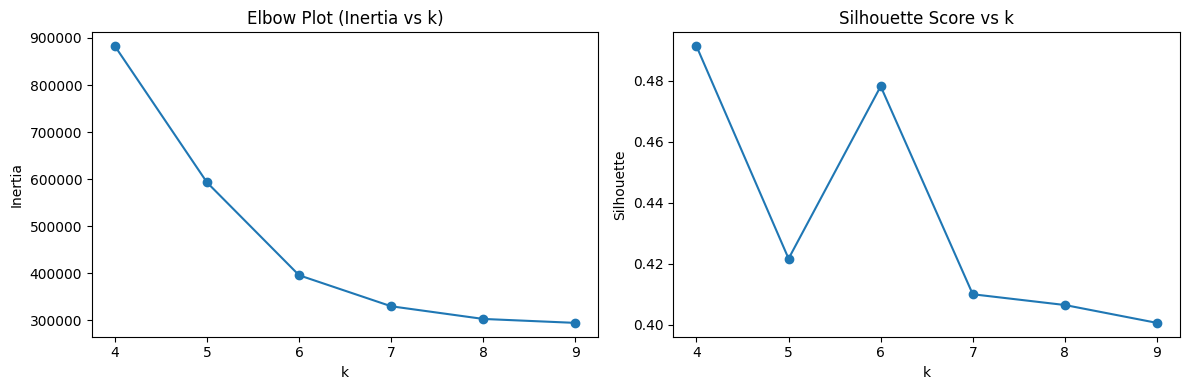

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# X should already exist (your FAMD matrix, e.g., X = X10_32)

# --- 1) Get silhouette series from your existing results ---
if "kmeans_results" in globals():
    ks = kmeans_results["k"].tolist()
    sil_scores = kmeans_results["silhouette"].tolist()
else:
    ks = k_list
    sil_scores = sil

# --- 2) Compute inertia for elbow (cheap + full-data safe) ---
inertia = []
for k in ks:
    km = KMeans(n_clusters=int(k), n_init="auto", random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

# combine into one table
eval_df = pd.DataFrame({"k": ks, "inertia": inertia, "silhouette": sil_scores})
display(eval_df)

# --- 3) Plot: Elbow + Silhouette (two panels) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(ks, inertia, marker="o")
ax[0].set_title("Elbow Plot (Inertia vs k)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(ks, sil_scores, marker="o")
ax[1].set_title("Silhouette Score vs k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()



## Imported Cluster Labels

Cluster assignments come from `versionb_kmeans_estimation_labels.csv` from Kmeans clustering in Rmarkdown. Please follow the following operations:
1. Run the code above. The elbow and silhouette score assists k selection.
2. Run the Rmarkdown with the created csv from above code.
3. Run the code below for visualization.

In [34]:
import pandas as pd

labels_path = "../Clustering/versionb_kmeans_estimation_labels.csv"
labels_df = pd.read_csv(labels_path, low_memory=False)
label_col = (
    "versionb_kmeans_estimation_labels"
    if "versionb_kmeans_estimation_labels" in labels_df.columns
    else "cluster_num"
)

if "customer_id" not in df.columns:
    original_csv_path = "../Clustering/clustering_Cleaned.csv"
    df_original = pd.read_csv(original_csv_path, low_memory=False)
    if len(df_original) != len(df):
        raise ValueError(
            f"Row count mismatch! Original: {len(df_original)}, Current: {len(df)}."
        )
    df = df.reset_index(drop=True)
    df["customer_id"] = df_original.reset_index(drop=True)["customer_id"].values

merge_cols = ["customer_id", label_col]
df = df.merge(
    labels_df[merge_cols].drop_duplicates("customer_id"),
    on="customer_id",
    how="left",
    validate="m:1",
)

if df[label_col].isna().any():
    raise ValueError(
        f"Missing labels for {df[label_col].isna().sum()} rows after merge on customer_id."
    )

df["cluster"] = df[label_col].astype(int)
df = df.drop(columns=[label_col])
if "customer_id" in df.columns:
    df = df.drop(columns=["customer_id"])

print("Cluster sizes (imported labels):")
print(df["cluster"].value_counts().sort_index())


Cluster sizes (imported labels):
cluster
1     5299
2     7949
3    20488
4    27674
Name: count, dtype: int64


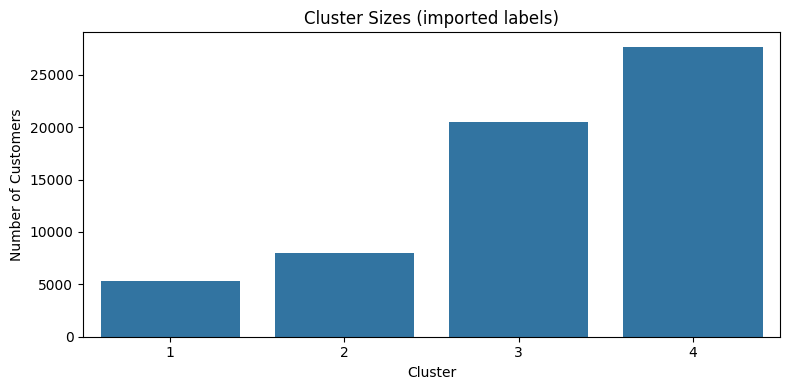

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_sizes = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values)
plt.title("Cluster Sizes (imported labels)")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## Result Analysis & Visualizations

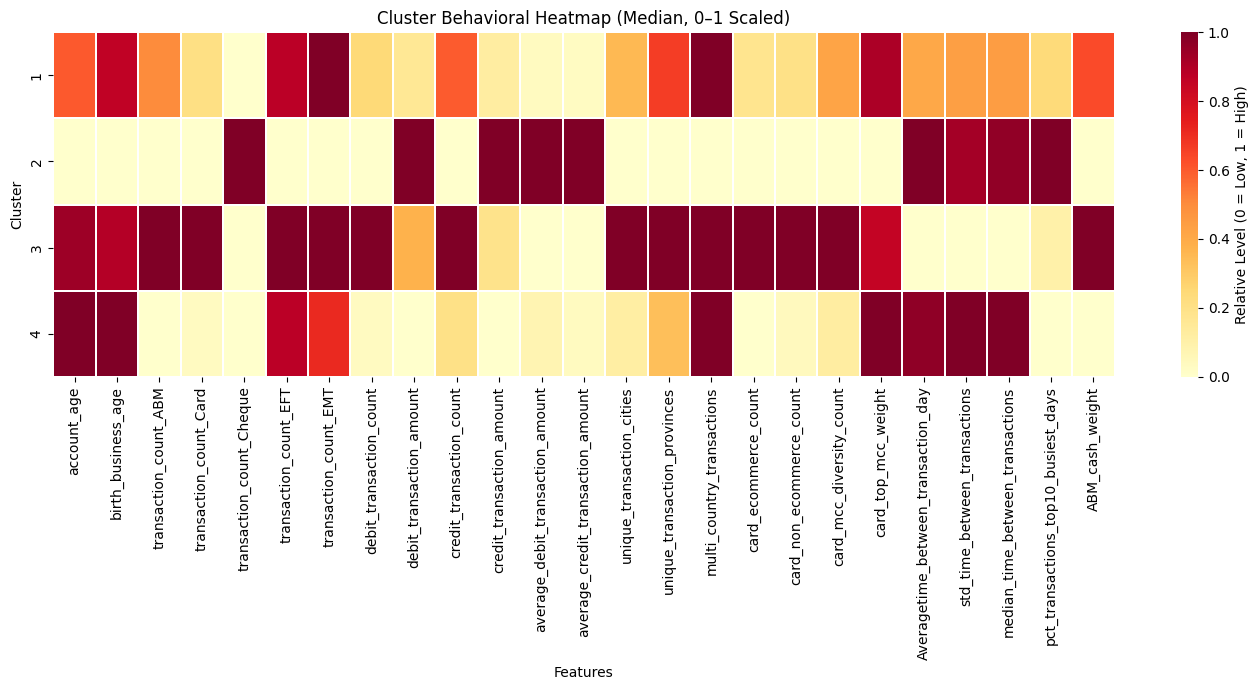

In [36]:
import numpy as np

num_cols = df.select_dtypes(include="number").columns.drop("cluster", errors="ignore")

# Cluster medians
cluster_medians = df.groupby("cluster")[num_cols].median()

# 0–1 scale per feature
cluster_medians_01 = (
    cluster_medians - cluster_medians.min()
) / (cluster_medians.max() - cluster_medians.min())

# Drop non-informative columns (all-white)
cluster_medians_01 = cluster_medians_01.loc[:, cluster_medians_01.max() > 0]

plt.figure(figsize=(14, 7))
sns.heatmap(
    cluster_medians_01,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Relative Level (0 = Low, 1 = High)"}
)

plt.title("Cluster Behavioral Heatmap (Median, 0–1 Scaled)")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


In [37]:


for cluster in sorted(cluster_medians_01.index):
    cluster_scores = cluster_medians_01.loc[cluster]
    
    # High scores: 0.65 to 1.0
    high_features = cluster_scores[(cluster_scores >= 0.65) & (cluster_scores <= 1.0)].sort_values(ascending=False)
    
    # Moderate scores: 0.35 to 0.65
    moderate_features = cluster_scores[(cluster_scores >= 0.35) & (cluster_scores < 0.65)].sort_values(ascending=False)
    
    high_list = list(high_features.index) if len(high_features) > 0 else []
    moderate_list = list(moderate_features.index) if len(moderate_features) > 0 else []
    
    
    print(f"cluster {cluster}: High: {high_list} Moderate: {moderate_list}")


cluster 1: High: ['transaction_count_EMT', 'multi_country_transactions', 'card_top_mcc_weight', 'transaction_count_EFT', 'birth_business_age', 'unique_transaction_provinces'] Moderate: ['ABM_cash_weight', 'account_age', 'credit_transaction_count', 'transaction_count_ABM', 'median_time_between_transactions', 'std_time_between_transactions', 'card_mcc_diversity_count', 'Averagetime_between_transaction_day', 'unique_transaction_cities']
cluster 2: High: ['transaction_count_Cheque', 'debit_transaction_amount', 'credit_transaction_amount', 'average_debit_transaction_amount', 'average_credit_transaction_amount', 'Averagetime_between_transaction_day', 'pct_transactions_top10_busiest_days', 'median_time_between_transactions', 'std_time_between_transactions'] Moderate: []
cluster 3: High: ['transaction_count_ABM', 'transaction_count_Card', 'transaction_count_EFT', 'transaction_count_EMT', 'debit_transaction_count', 'credit_transaction_count', 'unique_transaction_cities', 'unique_transaction_pro

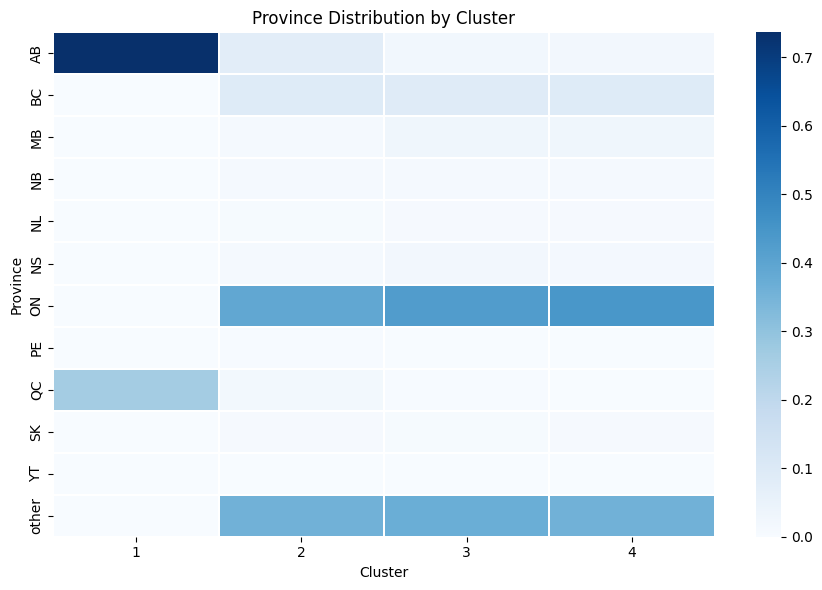

In [38]:
province_dist = pd.crosstab(
    df["province"],
    df["cluster"],
    normalize="columns"
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    province_dist,
    cmap="Blues",
    linewidths=0.3
)

plt.title("Province Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Province")
plt.tight_layout()
plt.show()


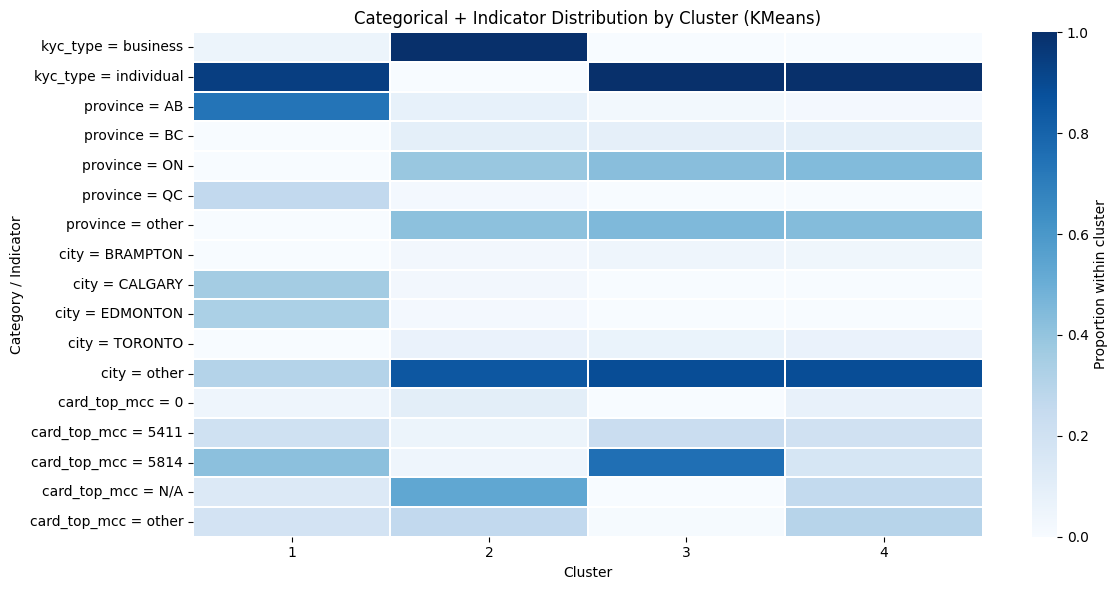

In [39]:


cluster_col = "cluster"

categorical_cols = [
    "kyc_type",
    "province",
    "city",
    "card_top_mcc"
]

top_n = 5
heatmap_blocks = []

# First normalize case: convert any "Other" to "other" to match existing data
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("Other", "other", regex=False)

for col in categorical_cols:
    top_vals = df[col].value_counts().head(top_n).index
    collapsed = df[col].where(df[col].isin(top_vals), "other")

    ct = pd.crosstab(
        collapsed,
        df[cluster_col],
        normalize="columns"
    )

    ct.index = [f"{col} = {v}" for v in ct.index]
    heatmap_blocks.append(ct)

# ---- combine everything ----
heatmap_df = pd.concat(heatmap_blocks)

# ---- plot ----
plt.figure(figsize=(12, max(6, 0.35 * heatmap_df.shape[0])))

sns.heatmap(
    heatmap_df,
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Proportion within cluster"}
)

plt.title("Categorical + Indicator Distribution by Cluster (KMeans)")
plt.xlabel("Cluster")
plt.ylabel("Category / Indicator")
plt.tight_layout()
plt.show()


In [40]:
# Save final dataframe with clusters
# First, restore customer_id from original dataset
original_csv_path = "../Clustering/clustering_Cleaned.csv"
df_original = pd.read_csv(original_csv_path)

# Safety check: verify row counts match
if len(df_original) != len(df):
    raise ValueError(f"Row count mismatch! Original: {len(df_original)}, Current: {len(df)}. Cannot safely restore customer_id.")

# Add customer_id back to the final dataframe using index alignment (safer than assuming order)
if 'customer_id' in df_original.columns:
    # Use index-based assignment to ensure correct alignment
    # Reset index to ensure both dataframes have 0, 1, 2, ... indices
    df_original_reset = df_original.reset_index(drop=True)
    df_reset = df.reset_index(drop=True)
    
    # Verify indices match
    if not df_reset.index.equals(df_original_reset.index):
        raise ValueError("Index mismatch! Cannot safely restore customer_id.")
    
    # Assign customer_id using index alignment
    df['customer_id'] = df_original_reset['customer_id'].values
    print(f"✓ customer_id restored from original dataset")
    print(f"  Verified: {len(df)} rows match between original and processed data")
else:
    raise ValueError("customer_id not found in original dataset!")

# Reorder columns to put customer_id first
cols = ['customer_id'] + [col for col in df.columns if col != 'customer_id']
df = df[cols]

# Save to CSV
output_path = "../Clustering/Kmeans_Final.csv"
df.to_csv(output_path, index=False)
print(f"\n✓ Final dataframe saved to: {output_path}")
print(f"  Shape: {df.shape}")
print(f"  Columns: {len(df.columns)}")
print(f"\nCluster distribution:")
print(df["cluster"].value_counts().sort_index())



C:\Users\houju\AppData\Local\Temp\ipykernel_45504\3503210439.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv(original_csv_path)


✓ customer_id restored from original dataset
  Verified: 61410 rows match between original and processed data

✓ Final dataframe saved to: ../Clustering/Kmeans_Final.csv
  Shape: (61410, 34)
  Columns: 34

Cluster distribution:
cluster
1     5299
2     7949
3    20488
4    27674
Name: count, dtype: int64


In [41]:
# Per cluster: kyc_type counts and % within that cluster
if "cluster" not in df.columns:
    raise ValueError("cluster column not found")
if "kyc_type" not in df.columns:
    raise ValueError("kyc_type column not found")

counts = pd.crosstab(df["cluster"], df["kyc_type"], dropna=False)
pct_within_cluster = counts.div(counts.sum(axis=1), axis=0).mul(100).round(2)

print("Counts by cluster × kyc_type:\n")
display(counts)
print("\n% within cluster (rows sum to 100):\n")
display(pct_within_cluster)

Counts by cluster × kyc_type:



kyc_type,business,individual
cluster,,
1,296,5003
2,7938,11
3,77,20411
4,0,27674



% within cluster (rows sum to 100):



kyc_type,business,individual
cluster,,
1,5.59,94.41
2,99.86,0.14
3,0.38,99.62
4,0.00,100.00


In [44]:
# Silhouette + Elbow score from imported cluster_num
import numpy as np
from sklearn.metrics import silhouette_score

# Use the exact matrix used at the top for this notebook
if "X10_32" in globals():
    X_eval = np.asarray(X10_32, dtype=np.float64)
elif "X" in globals():
    X_eval = np.asarray(X, dtype=np.float64)
else:
    raise ValueError("Expected X10_32 (or X) in memory. Run the top cells first.")

# Labels imported from labels_df and aligned with current df
if "df" in globals() and "cluster" in df.columns:
    y = df["cluster"].astype(int).to_numpy()
else:
    y = labels_df["cluster_num"].astype(int).to_numpy()

if X_eval.shape[0] != y.shape[0]:
    raise ValueError(f"Row mismatch: X has {X_eval.shape[0]} rows but labels have {y.shape[0]} rows.")

sil = silhouette_score(X_eval, y)

# Elbow score = within-cluster sum of squares using imported labels
elbow_score = 0.0
for lab in np.unique(y):
    pts = X_eval[y == lab]
    centroid = pts.mean(axis=0)
    elbow_score += ((pts - centroid) ** 2).sum()

print(f"Rows evaluated: {len(y):,}")
print(f"k (from cluster_num): {len(np.unique(y))}")
print(f"Silhouette score: {sil:.6f}")
print(f"Elbow score: {elbow_score:,.2f}")


Rows evaluated: 61,410
k (from cluster_num): 4
Silhouette score: 0.402747
Elbow score: 919,388.50
